# Change Analysis

[Click here](https://iom-tagapp-beta.pla.sh) to access the **IOM TAGGING (BETA) PLATFORM**

In [ ]:
from iomeval.llm_eval.changes import *

from fastcore.all import *
from iomeval.readers import load_evals
from pathlib import Path

In [ ]:
p = Path().home() / 'iomeval/data/requester_by_report_id.json'
lut = p.read_json()
evls_test = L(lut.keys())

ROOT_PATH = Path.home() / 'iomeval'
DATA_PATH = ROOT_PATH / 'data'
RESULTS_PATH = DATA_PATH/ 'results'
EVALS_PATH = ROOT_PATH / 'nbs/files/test/evaluations.json'

# Contains latest backed up data before new deployment
LATEST_TAG_PATH = Path.home() / 'tagapp/backups/20260311_115159/data'

evals = load_evals(EVALS_PATH)

In [ ]:
dfs = all_deltas(evls_test, RESULTS_PATH, LATEST_TAG_PATH)

In [ ]:
who = set(lut.values())
who


{'Andres', 'Davide', 'elma', 'ljeoma', 'pip', 'rogers'}

In [ ]:
# Automaticall generate changes report cells for all reports
rpts = [k for k,v in lut.items() if v=='Andres']
for rpt in rpts: await gen_report_cells(rpt, dfs, LATEST_TAG_PATH, RESULTS_PATH)

## What we have changed?

1. First of all, we **improved the consistency of what section of an evaluation report the model reads**. A "curation" step was added to the process in which a human selects the sections of the report that are more relevant to the tagging. This step used to be automatic (it was based on the "parsing" prompt that you reviewed) but we realized that several mistakes were being made by the model (probably because of the diversity in formatting and structure of evaluation reports, which not always follow a precise template). This is a major change with likely general consequences on the tagging. *Feedback from testers on which sections of the report should be fed to the model was considered*. 

Secondly, we made changes to the tagging prompts based on your feedback. Here are the main modifications (minor ones are not listed here but are available in the files used for the review):


2. **Excerpt-based analysis clarification**: Following the point above on the new report "curation" step, we asked the model to be explicit on the fact that only specific section are accessed (executive summary, introduction, background, evaluation scope, conclusions, recommendations, lessons learnt) in order not to give a false impression that the full report was being fed to the model. Hedged language is required throughout (e.g., "the excerpts suggest …", "based on the sections reviewed …"). *This follows up on comments from several testers - some asking more precise quotation outputs (something not possible at this stage - sorry!). The reasoning now is more transparent on the fact that the model is not reading the whole report (like a human would do when tagging; remember also that in earlier experiments, feeding the whole report to the model was inflating scores throughout and making the model unusable)*.

3. **GCM 23 downgrading**: Added an important note on GCM Objective 23 clarifying its revised scoring treatment. *This follows up on feedback from different testers suggesting that relevance with respect to this objective may have been exaggerated by the model*.

4. **SRF enablers reframing**: Introduced a critical distinction between enablers as institutional capacity versus programmatic tools. *This follows up on a point raised by Pip*.

5. **Relevance score range relabelling**: Tags now use "Not Relevant", "Peripheral" (formerly "Supplementary"), "Relevant", and "Fundamental". *This follows up on suggestion from Andres*.

6. **Terminology warning on "Findings"** — Analysts must not use "finding(s)" in their own analytical language, as this term carries a specific formal meaning in IOM evaluation reports. It may only be referenced when it appears in report excerpts themselves. *This clarification stems from Andres flagging overly broad or imprecise uses of "findings" generated by the LLM*.

7. **GCM descriptions added**: The description of the GCM objective used by the model is now fully in line with the GCM UN resolution document. *This is something we realized upon auditing the script*. For instance:
```
# Objective 1
## Title: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies
We commit to strengthen the global evidence base on international migration by improving and investing in the collection, analysis and dissemination of accurate , ...
To realize this commitment, we will draw from the following actions:
## Associated actions
- a. Elaborate and implement ...
- b. ...
...
```

Here are links to [new](https://github.com/franckalbinet/iomeval/tree/main/nbs/files/prompts) and [previous](https://github.com/franckalbinet/iomeval/tree/main/nbs/files/prompts/legacy) versions of the prompts.

How did these changes affect tagging?

## Score changes overview

**Based on all reports tagged so far (20)**. This is to give you a general sense of how the behavior of the model changed.

### GCM objectives

*Note: You might be unfamiliar with this type of visualization. It's called a [violin plot](https://en.wikipedia.org/wiki/Violin_plot). A violin plot combines a box plot with a smoothed estimate of the score distribution, making it easier to spot not just the median and spread, but also whether scores cluster around one or several values, something a box plot alone would miss.*


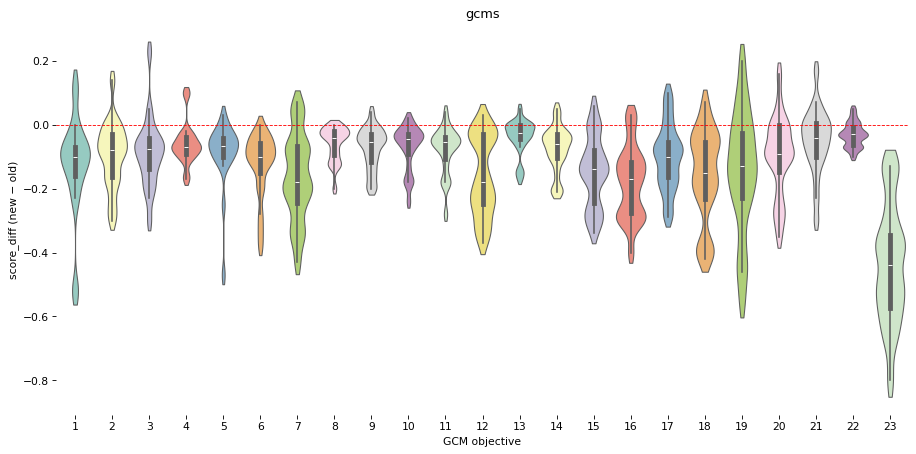

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective', figsize=(12, 6), dpi=77)

### SRF Enablers

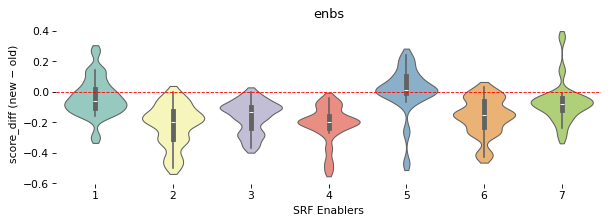

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers', figsize=(8, 3), dpi=77)

### SRF Cross-Cutting Priorities

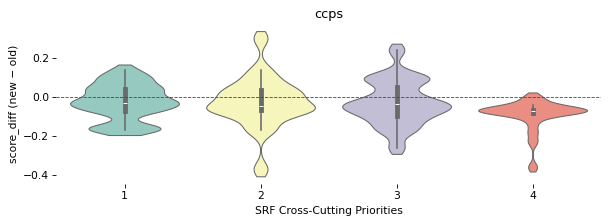

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities', figsize=(8, 3), dpi=77)

## Rank changes overview

Among all themes where previous relevance score was `> 0.83` (**FUNDAMENTAL**), what percentage of them have undergone a change in rank (`rank_diff != 0`)

In [ ]:
dfs[dfs.score_old > 0.83].groupby('mapping_type').apply(lambda x: 100 * (x.rank_diff != 0).sum() / len(x)).round(1).sort_values()

mapping_type
ccps    16.7
gcms    34.3
outs    40.7
enbs    44.4
dtype: float64

## Our interpretation

The score changes overview charts show a general decrease of the scores. In other words, the **model became more conservative** following the various changes made to the prompts.

The reduction in scores is more pronounced and generalized for GCM objectives, possibly due to the additional details on **GCM objectives** (change 7 above) that now the model has access to. However, the reductions yet remain moderate in magnitude, suggesting the prompt revisions recalibrated the model's behaviour without disrupting it fundamentally. The dramatic average score reduction for GCM objective 23 is something intended. *It means that the changes to the prompt worked, although your feedback will say if further calibration is needed*.  

**SRF Enablers** showed the highest rank instability (44.4%). This is also expected due to their reframing in the prompt (change 4).

**CCPs** were relatively unaffected by the changes in terms of average scores and ranking, which is consistent with the fact that none of the changes specifically targeted CCP scoring logic.

**Caveat**: the current general analysis is based on 20 reports only. Patterns, especially for the objectives less covered by our sample of reports, should be interpreted with caution.

## Inputs we need from you

- Do you agree with the overall interpretation of the changes?
- Do you find the new behaviour to be improved? 
- Please check, in the reports you asked us to tag, how the new behaviour has changed the items classified as fundamental. Do you find that accuracy and sensitivity have improved? Do you find the new reasonings better? 

## Per evaluation report

**REMINDER**, our "RELEVANCE SCORE FRAMEWORK" is as follows:
- score >= 0.84: **FUNDAMENTAL**
- 0.66 <= score < 0.83: **RELEVANT**
- 0.34 <= score < 0.66: **PERIPHERAL**
- score < 0.34: **NOT RELEVANT**

### Evaluation of the project “Regional Migration Policy and Knowledge Management Hub in South America”

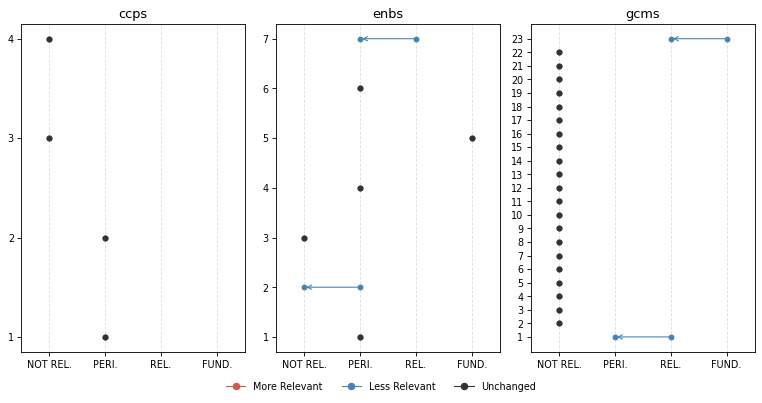

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '4c04ec0d3e651f7616190c6fc2dcfc18'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 5: Learning and Innovation | 0.92 |
| old | gcms | 23: Strengthen International Cooperation And Global Partnerships For Safe, Orderly And Regular Migration | 0.85 |
| new | enbs | 5: Learning and Innovation | 0.92 |

**⬇️ No Longer Fundamental**

#### GCMS 23: Strengthen international cooperation and global partnerships for safe, orderly and regular migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.72 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 23. The evaluation explicitly examines a regional cooperation mechanism (KM Hub) designed to strengthen coordination among migration actors in South America. The project aligns with UN Network on Migration, Global Compact on Migration, and IOM global mechanisms. Key findings address regional cooperation mechanisms, multi-stakeholder partnerships, technical assistance provision, and capacity building for migration governance. The strategy's seven pillars include 'Belonging to a valuable and growing system' emphasizing interconnected regional practice. Particularly valuable are: the findings on leveraging existing platforms for regional cooperation (Section 7 context); conclusions on coherence with global KM efforts (Conclusion 2); recommendations on strengthening regional coordination (Recommendations 3-4); and lessons learned on systems-level change for KM governance (Lessons 1-2). The report provides direct evidence on implementation of regional capacity building mechanisms. Actions 23a (technical assistance), 23c (local authority involvement), and 23e (bilateral/regional partnerships) are most relevant. The Executive Summary, Conclusions 1-3, and Recommendations sections would be particularly valuable for synthesis work.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 23, particularly regarding institutional capacity-building for migration governance and knowledge management as a foundation for coordinated international action. The project explicitly positions itself within IOM's governance pillar and is aligned with the UN Network on Migration, the Global Compact on Migration, the IOM Policy Hub, and IOM's Global Migration Data Analysis Centre — all mechanisms central to GCM Objective 23's vision of strengthened international cooperation architecture. The KM Hub is designed to support coordination across migration actors and to position IOM South America as a regional knowledge referent, which relates to actions 23a (technical assistance for GCM implementation) and 23d (capacity-building mechanisms). The Regional KM Strategy 2022-2027 appears to be an institutional mechanism for building the organizational infrastructure needed to support coherent, evidence-based migration governance across a multi-country region — directly relevant to the spirit of Objective 23. Conclusions 1, 2, and 8-10 in the excerpts address the strategy's alignment with global frameworks, its sustainability, and its role in strengthening IOM's regional coordination capacity. Recommendations 1-4 on governance, capacity development, and indicator frameworks would likely be of interest to synthesis specialists examining how international organizations build institutional capacity to support GCM implementation. Specialists should particularly review the sections on coherence (Conclusions 1-2), the Theory of Change discussion, and the sustainability conclusions (Conclusion 10), as these appear most directly relevant to Objective 23's focus on international cooperation architecture. It should be noted that this is a borderline case: the report primarily evaluates an internal IOM organizational initiative rather than an inter-state cooperation mechanism per se, and the international cooperation dimension is more contextual than analytical in places. Human reviewers should assess whether the institutional capacity-building focus provides sufficient evidence for a synthesis on Objective 23.</details>

### FINAL EVALUATION OF THE EU-IOM KNOWLEDGE MANAGEMENT HUB (KMH)

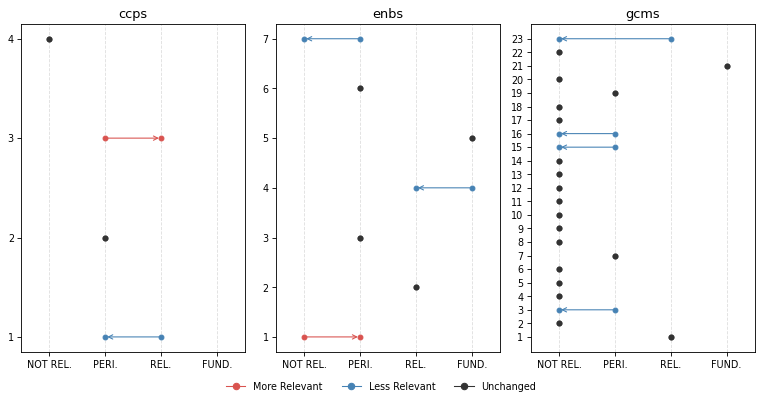

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '891448b7a4bf12763ea0579dd67e289d'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 4: Data and evidence | 0.87 |
| old | enbs | 5: Learning and Innovation | 0.91 |
| old | gcms | 21: Cooperate In Facilitating Safe And Dignified Return And Readmission, As Well As Sustainable Reintegration | 0.95 |
| new | enbs | 5: Learning and Innovation | 0.84 |
| new | gcms | 21: Cooperate In Facilitating Safe And Dignified Return And Readmission, As Well As Sustainable Reintegration | 0.95 |

**⬇️ No Longer Fundamental**

#### ENBS 4: Data and evidence

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.87 | 0.78 | 2 | 2 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Enabler 4 (Data and Evidence). The KMH's core mandate includes 'cross-regional harmonisation of M&E activities' to ensure 'reliable data for evidence-based programming' and 'comparative analysis across regions.' The evaluation explicitly assesses the M&E Package development, harmonized indicators, data collection systems, and evidence generation. Multiple findings directly address IOM's organizational capacity in data systems: Conclusion 6 notes contributions to 'more comparable data and more harmonised approaches,' while Recommendations 3 and 8 specifically address M&E Package revision and standardization. The evaluation questions include 'Quality of internal monitoring system and reporting' (Green). The report provides direct evidence on how IOM is building institutional capacity for data collection, management, and evidence use across reintegration operations. For synthesis specialists, the findings on M&E Package development, Conclusion 6 on harmonization achievements, and Recommendations 3 and 8 on future M&E institutionalization would be particularly valuable.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Enabler 4 (Data and Evidence), and importantly, the evidence appears to concern IOM's organizational capacity rather than merely data collection as a programmatic tool. The KMH's M&E Package and knowledge management functions are evaluated as institutional capacity-building efforts — the evaluation explicitly examines how IOM is developing systems for harmonized data collection, comparable data across operations, and evidence-based monitoring of reintegration outcomes at an organizational level. Evaluation question 3.2.3 ('Quality of internal monitoring system and reporting') and the associated conclusions (C2, C6) directly address IOM's data and evidence systems. The recommendations on completing a Roadmap for revising the institutional M&E Package, requiring standardized data collection across reintegration operations, and institutionalizing KM and M&E functions (C11) suggest substantive analysis of IOM's organizational data capacities. The lessons learned section also addresses the importance of outcome measurement and evidence generation at a systemic level. Synthesis specialists would likely want to prioritize the effectiveness section (3.5), the quality of design/monitoring section (3.2), and conclusions C2, C6, and C11, which appear to contain the most substantive institutional-level analysis of IOM's data and evidence capacities. The full report likely contains additional relevant evidence beyond what the excerpts reveal.</details>

### Final Internal Evaluation for Enhancing Knowledge on Remittances and Diaspora Engagement in South Sudan

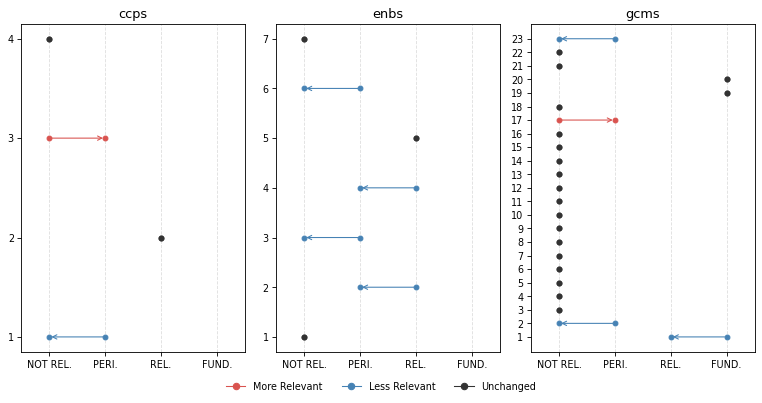

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '75bad4665ed458cce78740e3d86f72d0'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | gcms | 1: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies | 0.88 |
| old | gcms | 19: Create Conditions For Migrants And Diasporas To Fully Contribute To Sustainable Development In All Countries | 0.91 |
| old | gcms | 20: Promote faster, safer and cheaper transfer of remittances and foster financial inclusion of migrants | 0.92 |
| new | gcms | 19: Create Conditions For Migrants And Diasporas To Fully Contribute To Sustainable Development In All Countries | 0.90 |
| new | gcms | 20: Promote faster, safer and cheaper transfer of remittances and foster financial inclusion of migrants | 0.92 |

**⬇️ No Longer Fundamental**

#### GCMS 1: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.88 | 0.82 | 3 | 3 | 0 |

<details><summary>Reasoning (old)</summary>This report appears to be essential evidence for a synthesis on GCM Objective 1. The project's core focus is on conducting research to generate migration data - specifically a holistic survey on diaspora engagement and remittances in South Sudan. This directly aligns with Action 1d (collect and analyze data on contributions of migrants and diasporas to sustainable development) and Action 1j (develop country-specific migration profiles). The evaluation examines the effectiveness of a research study commissioned to address a significant data gap - since 2013, the Bank of South Sudan has not issued disaggregated data on overseas development assistance and there was no tracking mechanism for remittances. Key findings include: the remittances study successfully produced evidence-based resources, though the survey 'did not reach as many participants as initially anticipated' (lesson learned). The impact section notes an unexpected positive outcome - implementation of a 'transactional system to systematically capture inflows and outflows of all remittances' by the Bank of South Sudan, inspired by the study results. The recommendations section emphasizes conducting 'research feasibility assessments before commissioning large research projects.' For synthesis specialists, the Executive Summary, Findings on Effectiveness, Impact conclusions, and Lessons Learned sections would be particularly valuable for understanding challenges and successes in migration data collection in fragile contexts.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 1. The project's core activity was commissioning a remittances study to address a significant data gap — the Bank of South Sudan had not issued disaggregated data on overseas development assistance since 2013, and there was no tracking mechanism for remittance flows. The evaluation appears to substantively assess the quality, reach, and impact of this data collection effort, including disaggregation by gender and demographic characteristics. The excerpts suggest direct relevance to Action 1d (collecting data on effects and benefits of migration and diaspora contributions to sustainable development) and Action 1j (developing country-specific migration profiles including remittance transfer costs). The unexpected outcome of the Bank of South Sudan implementing a transactional system to capture remittance inflows/outflows — reportedly inspired by the study — is also directly relevant to Action 1i (enhancing collaboration between state units and statistical offices). The evaluation's findings on barriers to data collection (distrust among diaspora, low survey participation), lessons learned on feasibility assessment, and recommendations on communication plans would likely add value to a synthesis on evidence-based migration policymaking. Reviewers should prioritize the Effectiveness section (output 1.1 indicators), the Impact section on unintended effects, and the Lessons Learned section. Note that data collection is a means to an end in this project rather than the primary programmatic focus, which slightly limits depth on the mechanics of data systems.</details>

### Midterm Evaluation of IOM East and Horn of Africa Regional Strategy 2020 – 2024

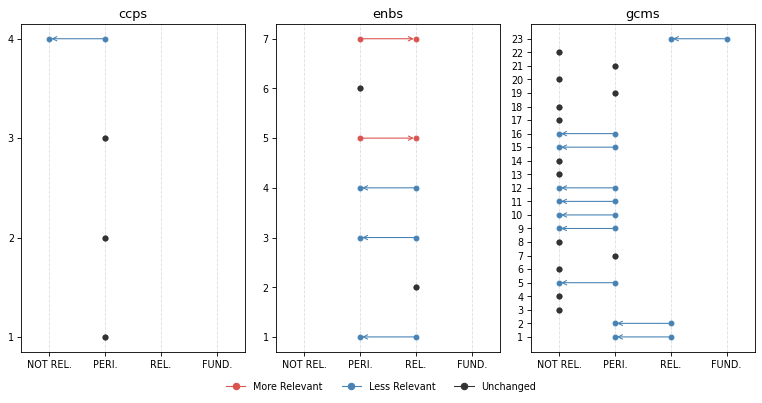

In [ ]:
plot_band_changes(dfs[dfs.evl_id == 'f409b3f9a0671ec69a8591c425a45c1d'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | gcms | 23: Strengthen International Cooperation And Global Partnerships For Safe, Orderly And Regular Migration | 0.85 |

**⬇️ No Longer Fundamental**

#### GCMS 23: Strengthen international cooperation and global partnerships for safe, orderly and regular migration

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.85 | 0.72 | 1 | 1 | 0 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 23. Regional cooperation and partnerships are central themes throughout the evaluation. The Regional Strategy explicitly addresses 'improving policy capacity and regional cooperation' as an institutional development priority. Key findings highlight IOM's partnerships with IGAD and EAC (Action 4), the Kampala Ministerial Declaration, and engagement with Member States, African Union, and Regional Economic Communities. The evaluation assesses IOM's 'regional leadership' role and 'whole-of-government structures, coherent policies and normative frameworks' (Priority 6). Recommendations emphasize consolidating partnerships with RECs, establishing consultation mechanisms, and maintaining coherence with international frameworks (GCM, SDGs). The analysis of regional coordination mechanisms, MoUs with regional bodies, and multi-stakeholder partnerships directly addresses Actions 23a, 23c, and 23e. For synthesis specialists, the findings on regional partnership effectiveness, the case studies on REC engagement, and recommendations on cooperation mechanisms would be particularly valuable - especially the analysis of how regional strategies facilitate coherent migration governance across the EHoA region.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 23, though with important caveats. The evaluation's primary subject — the IOM EHoA Regional Strategy 2020-2024 — is itself a regional governance and cooperation instrument, and the evaluation explicitly examines how IOM positions itself as a strategic actor within multilateral migration governance frameworks. This goes beyond ambient operational language: the evaluation assesses IOM's institutional role in shaping regional migration governance, its partnerships with RECs (IGAD, EAC, African Union), its alignment with global frameworks (GCM, SDGs, Kampala Declaration), and its capacity to influence migration policy at regional and national levels. These themes relate substantively to actions 23a (supporting collective GCM implementation), 23b (regional cooperation to address structural migration drivers), and 23e (bilateral/regional partnerships on migration policy). The excerpts suggest that the evaluation examines the Regional Strategy as a mechanism for operationalizing international cooperation — including MoUs with IGAD and EAC, joint regional programmes, and IOM's role within UNCTs and with Member States. The conclusions and recommendations sections appear particularly relevant, discussing IOM's leadership role, partnership consolidation, and alignment with international frameworks. A synthesis specialist would want to review the conclusions on IOM's regional governance role and the recommendations on partnership consolidation and framework coherence, while noting that the report's primary focus is on IOM's internal strategic planning effectiveness rather than on inter-state cooperation architecture per se. The full report likely contains more on this topic than the excerpts reveal.</details>

### THEMATIC EVALUATION OF IOM'S LABOUR MIGRATION AND MOBILITY STRATEGY AND INITIATIVES

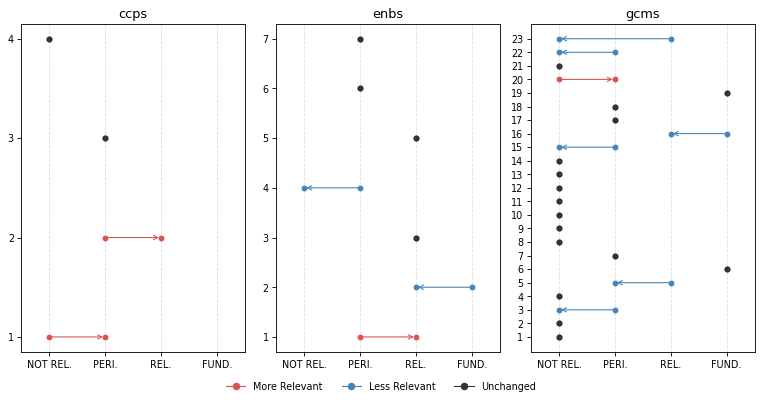

In [ ]:
plot_band_changes(dfs[dfs.evl_id == '760568a15e144bcfb88dbbd50247dc51'], figsize=(10, 5), dpi=77)

**Fundamental Themes**
| | Mapping | Theme | Score |
|---|---|---|---|
| old | enbs | 2: Partnership | 0.84 |
| old | gcms | 16: Empower Migrants And Societies To Realize Full Inclusion And Social Cohesion | 0.91 |
| old | gcms | 19: Create Conditions For Migrants And Diasporas To Fully Contribute To Sustainable Development In All Countries | 0.85 |
| old | gcms | 6: Facilitate Fair And Ethical Recruitment And Safeguard Conditions That Ensure Decent Work | 0.88 |
| new | gcms | 19: Create Conditions For Migrants And Diasporas To Fully Contribute To Sustainable Development In All Countries | 0.88 |
| new | gcms | 6: Facilitate Fair And Ethical Recruitment And Safeguard Conditions That Ensure Decent Work | 0.85 |

**⬇️ No Longer Fundamental**

#### ENBS 2: Partnership

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.84 | 0.76 | 1 | 2 | -1 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on Enabler 2 (Partnership). Partnership is explicitly identified as one of the evaluation's key themes, with 'Partnerships building' listed as a major finding area in the executive summary. The evaluation examines IOM's collaborative work with governments, UN agencies (particularly ILO), civil society organizations, private sector actors, and diaspora communities. Key findings address partnership quality, the 2022 retreat as 'a milestone in securing stronger inclusion and collaboration,' and external partnerships with 'a wide variety of external partners.' The coherence section provides substantive analysis of partnership effectiveness, noting 'successful engagement with a wide variety of external partners' and 'increasing engagement with new partner types, in particular the private sector.' Multiple recommendations directly address partnership strengthening: Recommendation 3 ('Nurture relationships and maximise complementarity'), Recommendation 7 (staff awareness of partnership guidance), and Recommendation 2 (systematic approach to partnerships). The report specifically notes the need to 'delineate each agency's remits and added value' with ILO and discusses IOM's role as 'convener' in the migration space. For synthesis specialists, the coherence findings, the analysis of IOM's convening role, and recommendations 2, 3, and 7 would be particularly valuable for understanding IOM's partnership capacities and areas for organizational development.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on Enabler 2 (Partnership). The evaluation appears to examine IOM's partnership practices at an organizational level — assessing how the LMI division builds and sustains relationships with external actors including UN agencies, governments, civil society, and the private sector — rather than evaluating partnerships merely as a delivery mechanism for a single project. The excerpts suggest that partnership is one of the explicit evaluation dimensions: the Coherence criterion in the OECD-DAC framework is applied to assess IOM's engagement with external partners, and the conclusions note 'successful engagement with a wide variety of external partners' alongside areas for improvement such as creating 'a more systematic approach to collaboration.' Overarching Recommendation 3 specifically addresses maximizing complementarity with ILO, UNDP, and the World Bank, and strengthening private sector engagement. Recommendation 2 calls for a 'centralised, systematic and cohesive approach to programming' to address silos and improve institutional cohesion. The evaluation also highlights IOM's convening role — including organizing the Global Diaspora Summit — as an institutional partnership capacity. However, partnership is one of several themes covered alongside funding, workforce, and internal systems. For a synthesis specialist, the Coherence section findings, Overarching Recommendations 2 and 3, and the discussion of private sector engagement and UN agency coordination would appear to be the most relevant sections to prioritize.</details>

#### GCMS 16: Empower migrants and societies to realize full inclusion and social cohesion

| score_old | score_new | rank_old | rank_new | rank_diff |
|---|---|---|---|---|
| 0.91 | 0.82 | 1 | 3 | -2 |

<details><summary>Reasoning (old)</summary>This report would likely be essential for a synthesis on GCM Objective 16. Social inclusion is explicitly part of the evaluated division's name and mandate ('Labour Mobility and Social Inclusion Division'). The evaluation's primary purpose includes assessing IOM's strategic approach to 'social inclusion.' The report identifies 'Integration, Social Inclusion and Cohesion' as one of six focus areas, aiming to 'develop migrants, communities and governments capacities to achieve full inclusion and social cohesion across the migration continuum.' Multiple findings address migrant integration, social cohesion outcomes, and inclusion programming. Actions 16a (integration best practices), 16c (inclusion policy goals), and 16f (community centres and migrant participation) are directly relevant. For a synthesis specialist, the effectiveness findings on migrant inclusion/integration, the analysis of IOM's role in empowering migrants and communities as development agents, and recommendations on enhancing IOM's connection with local communities (Recommendation 14) would be particularly valuable. The conclusions table explicitly identifies achievements and areas for improvement related to inclusion programming.</details>

---

<details><summary>Reasoning (new)</summary>Based on the excerpts reviewed, this report would likely contribute meaningful evidence to a synthesis on GCM Objective 16. Social inclusion and cohesion appear as explicit strategic focus areas of the LMI division ('Integration, Social Inclusion and Cohesion: Aiming to develop migrants, communities and governments capacities to achieve full inclusion and social cohesion across the migration continuum'). The report discusses IOM's efforts to empower migrants as development agents, amplify migrants' voices, and foster social cohesion — aligning with actions 16a, 16c, 16d, and 16f. The evaluation assesses IOM's effectiveness in migrant inclusion and integration, with the conclusions table identifying 'migrant inclusion/integration' as an area of strong impact. The Theory of Change includes outputs on 'protection-focused, social programming' and 'fiscal inclusion of diversity.' For a synthesis specialist, the sections on LMI strategic focus areas, the conclusions on effectiveness and impact in inclusion/integration, and the recommendations on cross-cutting themes and community engagement would appear particularly valuable. The full report likely contains more programmatic detail on social inclusion initiatives beyond what the excerpts reveal.</details>